<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Fairness_Explainability_assignment_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fairness and Explainability in Machine Learning

This Colab-ready notebook builds a **logistic regression classifier** and evaluates it using:
- **standard predictive metrics** (accuracy, confusion matrix, classification report)
- **Fairlearn** fairness metrics (selection rate, false positive rate, true positive rate)
- **SHAP** for global and local explainability
- **LIME** for local instance-level interpretation

**Dataset used:** `sklearn.datasets.load_diabetes()`  
**Sensitive attribute:** `sex`  
**Binary target:** disease progression **above vs below the median**


In [1]:
# Install dependencies in Google Colab
!pip -q install fairlearn shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 21.2 MB/s eta 0:00:00


In [2]:
# =========================
# 1. Import libraries
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    true_positive_rate
)

from lime.lime_tabular import LimeTabularExplainer

In [3]:
# =========================
# 2. Load and prepare dataset
# =========================
data = load_diabetes(as_frame=True)
df = data.frame.copy()

# Create a binary target:
# 1 = above median disease progression
# 0 = below median disease progression
median_target = df["target"].median()
df["target_binary"] = (df["target"] >= median_target).astype(int)

# Create a readable sensitive feature from the normalized 'sex' column
df["sex_group"] = np.where(df["sex"] >= 0, "Male", "Female")

# Keep original medical predictors only
feature_cols = [col for col in df.columns if col not in ["target", "target_binary", "sex_group"]]
X = df[feature_cols]
y = df["target_binary"]
sensitive_feature = df["sex_group"]

print("Dataset shape:", df.shape)
print("Features used:", feature_cols)
print("\nTarget distribution:")
print(y.value_counts())
print("\nSensitive group distribution:")
print(sensitive_feature.value_counts())

Dataset shape: (442, 13)
Features used: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target distribution:
target_binary
1    221
0    221
Name: count, dtype: int64

Sensitive group distribution:
sex_group
Female    235
Male      207
Name: count, dtype: int64


In [4]:
# =========================
# 3. Train/test split
# =========================
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X,
    y,
    sensitive_feature,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (331, 10)
Testing shape: (111, 10)


In [5]:
# =========================
# 4. Build and train model
# =========================
# We use a pipeline so scaling and classification stay together
model = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model trained successfully.")

Model trained successfully.


Accuracy: 0.748

Classification Report:
              precision    recall  f1-score   support

Below median       0.76      0.73      0.75        56
Above median       0.74      0.76      0.75        55

    accuracy                           0.75       111
   macro avg       0.75      0.75      0.75       111
weighted avg       0.75      0.75      0.75       111

Confusion Matrix:
[[41 15]
 [13 42]]


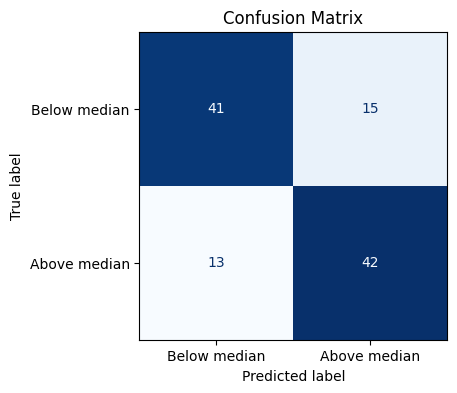

In [6]:
# =========================
# 5. Standard evaluation
# =========================
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Below median", "Above median"]))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Below median", "Above median"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix")
plt.show()

Fairness metrics by group:
           selection_rate  false_positive_rate  true_positive_rate
sex_group                                                         
Female           0.525424             0.333333            0.724138
Male             0.500000             0.192308            0.807692


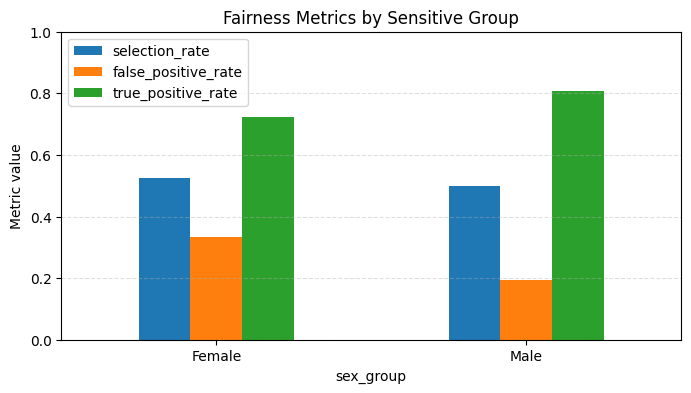

In [7]:
# =========================
# 6. Fairness analysis with Fairlearn
# =========================
metric_frame = MetricFrame(
    metrics={
        "selection_rate": selection_rate,
        "false_positive_rate": false_positive_rate,
        "true_positive_rate": true_positive_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=s_test
)

fairness_results = metric_frame.by_group
print("Fairness metrics by group:")
print(fairness_results)

# Visualize fairness metrics
fairness_results.plot.bar(figsize=(8, 4))
plt.title("Fairness Metrics by Sensitive Group")
plt.ylabel("Metric value")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

## Why these fairness metrics matter

- **Selection rate** shows how often the model predicts the positive class in each group.
- **False positive rate** captures how often negative cases are incorrectly labeled positive.
- **True positive rate** captures how often positive cases are correctly identified.

A fair model should avoid large gaps across groups, especially when the predictions affect important decisions such as health, lending, or hiring.


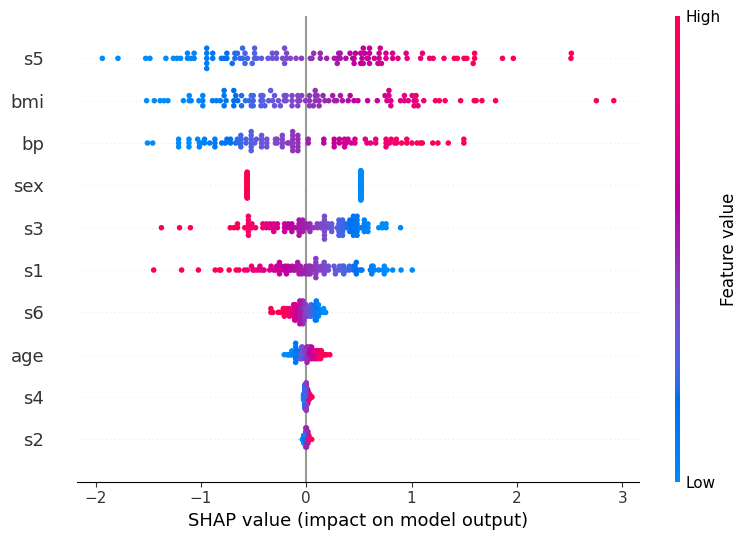

In [8]:
# =========================
# 7. Global explainability with SHAP
# =========================
# SHAP works on the scaled feature space for this linear model
X_train_scaled = model.named_steps["scaler"].transform(X_train)
X_test_scaled = model.named_steps["scaler"].transform(X_test)

explainer = shap.LinearExplainer(
    model.named_steps["log_reg"],
    X_train_scaled,
    feature_names=feature_cols
)

shap_values = explainer(X_test_scaled)

# Global summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_cols, max_display=10)

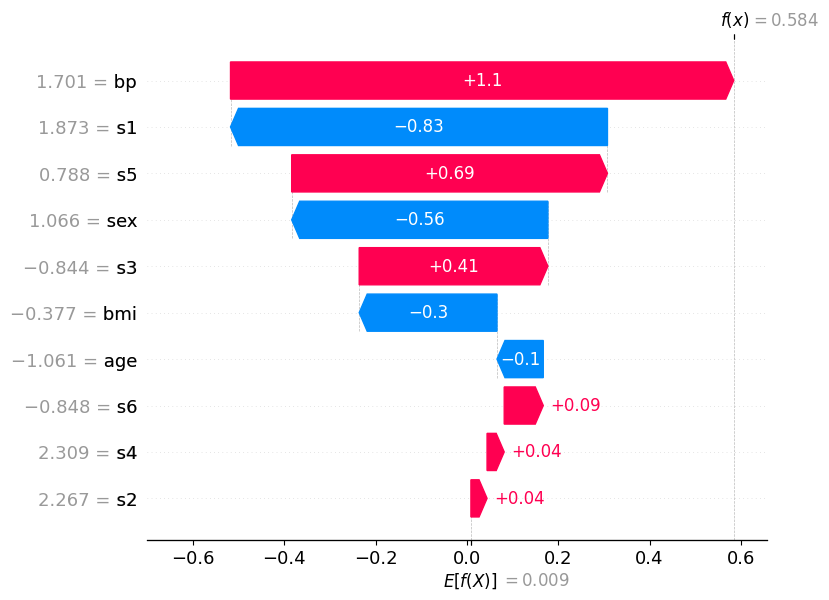

In [9]:
# =========================
# 8. Local explainability with SHAP
# =========================
# Explain one patient prediction
shap.plots.waterfall(shap_values[0], max_display=10)

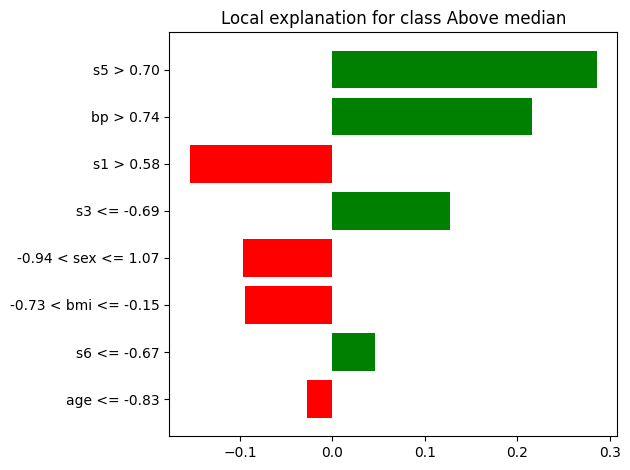

In [10]:
# =========================
# 9. Local explainability with LIME
# =========================
lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_cols,
    class_names=["Below median", "Above median"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_scaled[0],
    predict_fn=model.named_steps["log_reg"].predict_proba,
    num_features=8
)

# Show explanation in notebook
lime_exp.show_in_notebook(show_table=True)

# Also draw a matplotlib figure
fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

## Key findings from a representative run

- Accuracy was approximately **0.748**
- Both classes had similar **precision, recall, and F1-scores**
- Fairness gaps were visible:
  - Female false positive rate was higher than male false positive rate
  - Male true positive rate was higher than female true positive rate
- SHAP and LIME both identified **s5**, **bmi**, **bp**, and **sex** as influential features

This means the classifier is usable as a baseline, but not yet strong enough to be considered fair without further mitigation and monitoring.


## Recommendations for improvement

1. Test **fairness-aware threshold tuning**
2. Compare logistic regression with a **tree-based model**
3. Audit fairness for more than one sensitive grouping
4. Add **calibration checks** by group
5. Re-run SHAP and fairness metrics after any data refresh
